# Experiment 0: short pilots and computing cost

The 32 short pilots cover four bases × two learning-rate extremes × two adaptation modes × two tasks on the first dataset partition. They run for 250 successful updates.

Use them to investigate failures, GPU memory and timing, not to select a winner on held-out performance. Extrapolation from a short run is provisional; table size and monitoring overhead make update costs uneven.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from IPython.display import display
from src.visualize import style
from src.visualize.figures import FigureSaver
from src.visualize import campaign as cp
from src.data.dataset_names import display_frame
from src.visualize.inputs import analysis_root
style.apply()
sink = FigureSaver('experiment0/02_short_pilots')
report = cp.NotebookReport('Experiment 0: short pilots and computing cost')


## 1. Pilot coverage

Check the planned trial denominator and failures before interpreting costs.

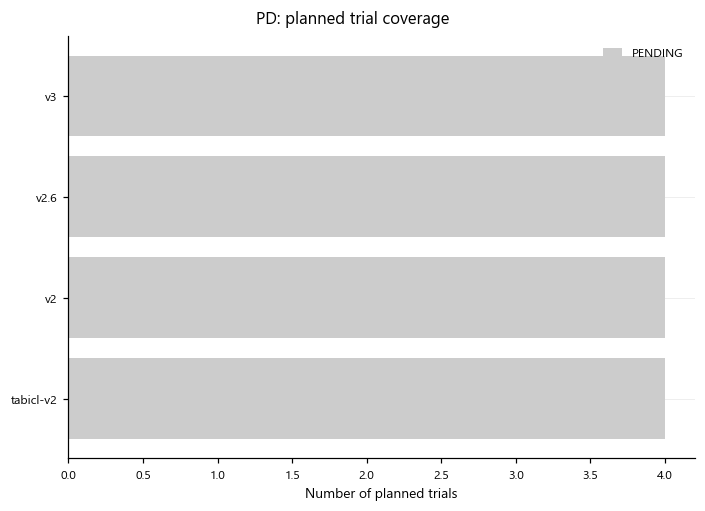

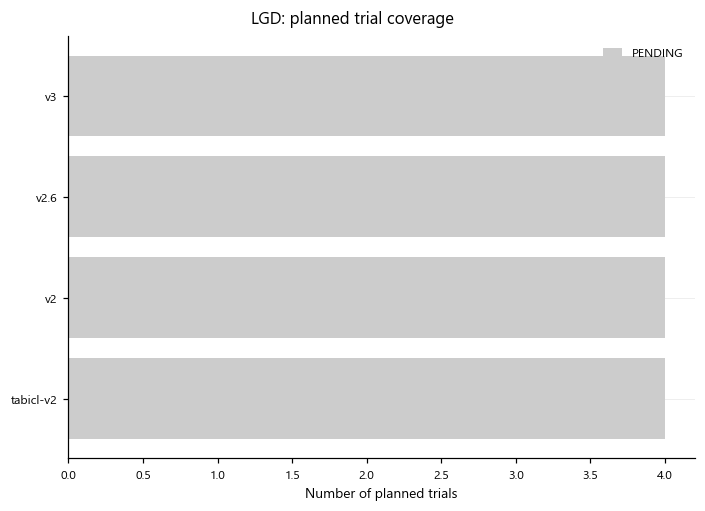

In [2]:
pilots = [cp.load_campaign(0, track, 'pilot') for track in ('pd','lgd')]
for pilot in pilots:
    cp.show(sink, cp.plot_coverage(pilot))
report.add('1. Pilot coverage', '\n\n'.join(cp.coverage_summary(c) for c in pilots))

## 2. Early behavior

Only predefined learning-rate extremes are compared. Panels fix base and adaptation, with equal dataset weighting and explicit gaps for missing milestones.

In [3]:
for pilot in pilots:
    cp.show(sink, cp.plot_trajectory_pages(pilot))
report.add('2. Early behavior', '\n\n'.join(c.track.upper()+'\n'+cp.effect_summary(cp.endpoint_effects(c)) for c in pilots))

No measurements available for this section yet.
No measurements available for this section yet.


## 3. Time, memory and numerical diagnostics

Separate seconds per update, allocated GPU hours, peak memory, data waiting and skipped updates. These are different bottlenecks, and require different remedies.

In [4]:
for pilot in pilots:
    cp.show(sink, cp.plot_optimization(pilot, 'train_loss'))
    cp.show(sink, cp.plot_diagnostics(pilot))
    display(display_frame(cp.diagnostics(pilot)).drop(columns=['final_ckpt_path','source_file','train_dataset_ids','test_dataset_ids'], errors='ignore'))
report.add('3. Resource diagnostics', '\n\n'.join(c.track.upper()+'\n'+cp.diagnostics(c).select_dtypes('number').describe().round(4).to_string() for c in pilots))

No measurements available for this section yet.
No measurements available for this section yet.


,trial_name,base,learning_rate,l2sp_lambda,frozen,sampling,seed,partition,status
0,cpt_pilot_v4_s00_pd_tabpfn-v2-classifier-v2_de...,v2,3.000000e-07,0.003,False,one_sample,42,0,PENDING
1,cpt_pilot_v4_s00_pd_tabpfn-v2-classifier-v2_de...,v2,3.000000e-07,0.003,True,one_sample,42,0,PENDING
2,cpt_pilot_v4_s00_pd_tabpfn-v2-classifier-v2_de...,v2,3.000000e-05,0.003,False,one_sample,42,0,PENDING
3,cpt_pilot_v4_s00_pd_tabpfn-v2-classifier-v2_de...,v2,3.000000e-05,0.003,True,one_sample,42,0,PENDING
4,cpt_pilot_v4_s00_pd_tabpfn-v2.6-classifier-v2....,v2.6,3.000000e-07,0.003,False,one_sample,42,0,PENDING
5,cpt_pilot_v4_s00_pd_tabpfn-v2.6-classifier-v2....,v2.6,3.000000e-07,0.003,True,one_sample,42,0,PENDING
6,cpt_pilot_v4_s00_pd_tabpfn-v2.6-classifier-v2....,v2.6,3.000000e-05,0.003,False,one_sample,42,0,PENDING
7,cpt_pilot_v4_s00_pd_tabpfn-v2.6-classifier-v2....,v2.6,3.000000e-05,0.003,True,one_sample,42,0,PENDING
8,cpt_pilot_v4_s00_pd_tabpfn-v3-classifier-v3_de...,v3,3.000000e-07,0.003,False,one_sample,42,0,PENDING
9,cpt_pilot_v4_s00_pd_tabpfn-v3-classifier-v3_de...,v3,3.000000e-07,0.003,True,one_sample,42,0,PENDING


No measurements available for this section yet.
No measurements available for this section yet.


,trial_name,base,learning_rate,l2sp_lambda,frozen,sampling,seed,partition,status
0,cpt_pilot_v4_s00_lgd_tabpfn-v2-regressor-v2_de...,v2,3.000000e-07,0.003,False,one_sample,42,0,PENDING
1,cpt_pilot_v4_s00_lgd_tabpfn-v2-regressor-v2_de...,v2,3.000000e-07,0.003,True,one_sample,42,0,PENDING
2,cpt_pilot_v4_s00_lgd_tabpfn-v2-regressor-v2_de...,v2,3.000000e-05,0.003,False,one_sample,42,0,PENDING
3,cpt_pilot_v4_s00_lgd_tabpfn-v2-regressor-v2_de...,v2,3.000000e-05,0.003,True,one_sample,42,0,PENDING
4,cpt_pilot_v4_s00_lgd_tabpfn-v2.6-regressor-v2....,v2.6,3.000000e-07,0.003,False,one_sample,42,0,PENDING
5,cpt_pilot_v4_s00_lgd_tabpfn-v2.6-regressor-v2....,v2.6,3.000000e-07,0.003,True,one_sample,42,0,PENDING
6,cpt_pilot_v4_s00_lgd_tabpfn-v2.6-regressor-v2....,v2.6,3.000000e-05,0.003,False,one_sample,42,0,PENDING
7,cpt_pilot_v4_s00_lgd_tabpfn-v2.6-regressor-v2....,v2.6,3.000000e-05,0.003,True,one_sample,42,0,PENDING
8,cpt_pilot_v4_s00_lgd_tabpfn-v3-regressor-v3_de...,v3,3.000000e-07,0.003,False,one_sample,42,0,PENDING
9,cpt_pilot_v4_s00_lgd_tabpfn-v3-regressor-v3_de...,v3,3.000000e-07,0.003,True,one_sample,42,0,PENDING


## 4. Resource decision

Choose measured per-base/per-mode time requests with a margin, accounting for monitoring and setup. Shorter honest requests can fit backfill opportunities; queue priority is not guaranteed by a short request alone.

In [5]:
report.add('4. Resource decision', 'Use measured pilot costs and existing row-cap probes. Do not increase row caps or launch the main grid from the null-control timing extrapolation.')

## Summary

The following text repeats the sections in order. It is included verbatim in `All_Results.md`.

In [6]:
print(report.summary(sink))

Experiment 0: short pilots and computing cost

1. Pilot coverage
Run cpt_pilot_v4; PD; 16 planned trials; target 250 successful updates.
status
PENDING    16
0 trajectory records; 0 benchmark fold records.

Run cpt_pilot_v4; LGD; 16 planned trials; target 250 successful updates.
status
PENDING    16
0 trajectory records; 0 benchmark fold records.

2. Early behavior
PD
No matched measurements available; absence is not a zero effect.

LGD
No matched measurements available; absence is not a zero effect.

3. Resource diagnostics
PD
       learning_rate  l2sp_lambda  seed  partition
count           16.0       16.000  16.0       16.0
mean             0.0        0.003  42.0        0.0
std              0.0        0.000   0.0        0.0
min              0.0        0.003  42.0        0.0
25%              0.0        0.003  42.0        0.0
50%              0.0        0.003  42.0        0.0
75%              0.0        0.003  42.0        0.0
max              0.0        0.003  42.0        0.0

LGD
  